In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def build_model():
    tf.keras.utils.set_random_seed(42)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(4,)),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(3, activation="softmax"),
    ])

In [3]:
EPOCHS = 100
LR = 0.01

optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=LR),
    "Adam": tf.keras.optimizers.Adam(learning_rate=LR),
}

histories = {}
results = {}
models = {}

for name, opt in optimizers.items():
    model = build_model()
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    hist = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=16,
                     validation_data=(X_test, y_test), verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    histories[name] = hist.history
    results[name] = (test_loss, test_acc)
    models[name] = model

    print(f"{name} -> Final train loss: {hist.history['loss'][-1]:.4f} | "
          f"Final train acc: {hist.history['accuracy'][-1]:.4f} | "
          f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

SGD -> Final train loss: 0.3268 | Final train acc: 0.9000 | Test loss: 0.3727 | Test acc: 0.8000
Adam -> Final train loss: 0.0352 | Final train acc: 0.9833 | Test loss: 0.0709 | Test acc: 0.9667


In [4]:
EPOCHS = 100
LR = 0.01

optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=LR),
    "Adam": tf.keras.optimizers.Adam(learning_rate=LR),
}

histories = {}
results = {}
models = {}

for name, opt in optimizers.items():
    model = build_model()
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    hist = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=16,
                     validation_data=(X_test, y_test), verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    histories[name] = hist.history
    results[name] = (test_loss, test_acc)
    models[name] = model

    print(f"{name} -> Final train loss: {hist.history['loss'][-1]:.4f} | "
          f"Final train acc: {hist.history['accuracy'][-1]:.4f} | "
          f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

SGD -> Final train loss: 0.3268 | Final train acc: 0.9000 | Test loss: 0.3727 | Test acc: 0.8000
Adam -> Final train loss: 0.0352 | Final train acc: 0.9833 | Test loss: 0.0709 | Test acc: 0.9667


Optimizer  | Train Loss | Train Acc | Test Loss | Test Acc
----------------------------------------------------------
SGD        |     0.3268 |    0.9000 |    0.3727 |   0.8000
Adam       |     0.0352 |    0.9833 |    0.0709 |   0.9667

Classification report - SGD
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.833     0.500     0.625        10
   virginica      0.643     0.900     0.750        10

    accuracy                          0.800        30
   macro avg      0.825     0.800     0.792        30
weighted avg      0.825     0.800     0.792        30


Classification report - Adam
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      1.000     0.900     0.947        10
   virginica      0.909     1.000     0.952        10

    accuracy                          0.967        30
   macro avg      0.970     0.967     0.967        3

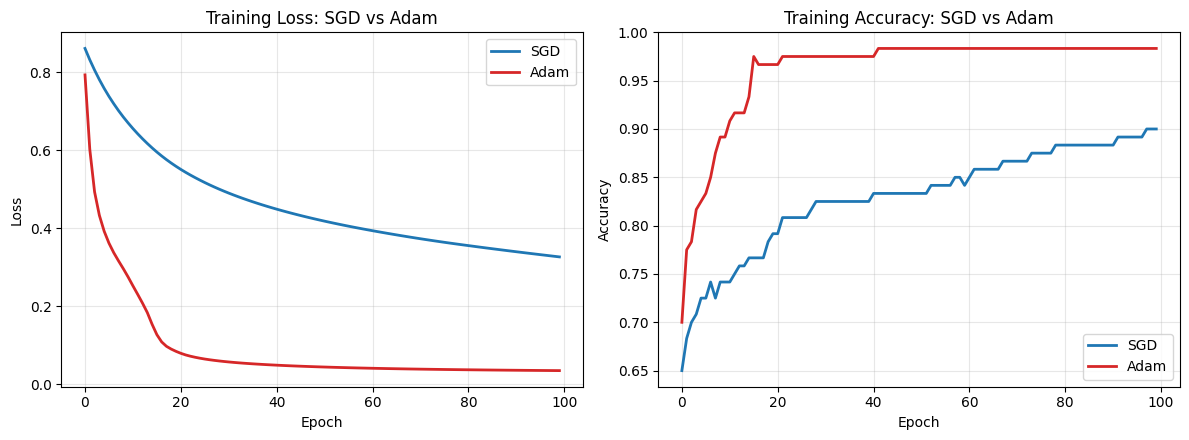

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# (assumes histories, results and models were stored during Task 2 training)

# 1. Summary table
print(f"{'Optimizer':<10} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8}")
print("-" * 58)
for name in optimizers:
    h = histories[name]
    print(f"{name:<10} | {h['loss'][-1]:>10.4f} | {h['accuracy'][-1]:>9.4f} | "
          f"{results[name][0]:>9.4f} | {results[name][1]:>8.4f}")

# 2. Classification report for each optimizer
for name, model in models.items():
    preds = np.argmax(model.predict(X_test, verbose=0), axis=1)
    print(f"\nClassification report - {name}")
    print(classification_report(y_test, preds, target_names=iris.target_names, digits=3))

# 3. Loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"SGD": "#1f77b4", "Adam": "#d62728"}
for name, h in histories.items():
    axes[0].plot(h["loss"], label=name, color=colors[name], linewidth=2)
    axes[1].plot(h["accuracy"], label=name, color=colors[name], linewidth=2)
axes[0].set_title("Training Loss: SGD vs Adam")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[1].set_title("Training Accuracy: SGD vs Adam")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
for a in axes:
    a.legend(); a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("optimizer_comparison.png", dpi=200)